In [1]:
import sys, json, warnings
sys.path.insert(0, "../src")
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True, "grid.alpha": 0.25})
BAD, GOOD, NEUTRAL, ACCENT = "#c0392b", "#1e8449", "#7f8c8d", "#2c6fbb"
RES = "../data/results/"


# P7 - Heavy-tailed revenue metrics

## 1. What goes wrong
A few whale customers dominate revenue variance. Revenue tests then have very low power, and one whale landing in one arm can swing the result.

## 2. Simulate

In [2]:
from abtest.pitfalls import heavy_tails
ht = heavy_tails.heavy_tail_study(whale_rates=(0, 0.005), lifts=(0.0, 0.10), n_sims=150, users_per_day=2_000)
ht.pivot_table(index=['whale_rate', 'true_conv_lift'], columns='method', values='reject_rate').round(3)

method                     cuped  welch  winsorized_p99
whale_rate true_conv_lift                              
0.000      0.0             0.053  0.060           0.047
           0.1             0.200  0.187           0.340
0.005      0.0             0.000  0.000           0.047
           0.1             0.053  0.040           0.313

## 3. Quantify the damage

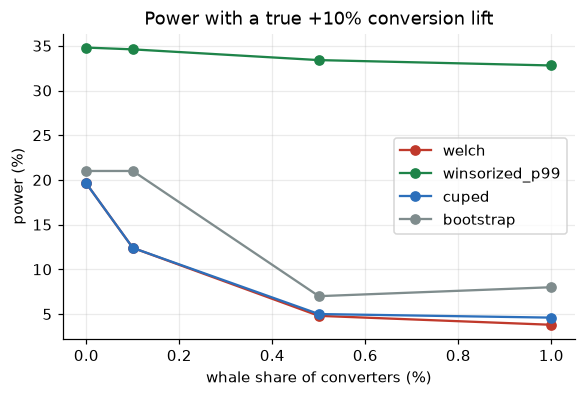

In [3]:
full = pd.read_csv(RES + 'p7_heavy_tails.csv')
fig, ax = plt.subplots(figsize=(6, 3.6))
for m, c in (('welch', BAD), ('winsorized_p99', GOOD), ('cuped', ACCENT), ('bootstrap', NEUTRAL)):
    d = full[(full.method == m) & (full.true_conv_lift == 0.10)]
    if len(d): ax.plot(d.whale_rate * 100, d.reject_rate * 100, 'o-', color=c, label=m)
ax.legend(); ax.set(xlabel='whale share of converters (%)', ylabel='power (%)', title='Power with a true +10% conversion lift'); plt.show()

## 4. Detect

Look at the distribution: share of revenue from the top 0.1% of users, and whether significance flips after winsorising (health checker: **Outliers**).

## 5. Fix

Winsorise at a cap computed on the **pooled** data (per-arm caps would bias the comparison), or use a bootstrap or CUPED. Note that winsorising changes the question: you estimate the effect on capped revenue, not true revenue.

## 6. Verify the fix

In [4]:
print(full.pivot_table(index=['whale_rate', 'true_conv_lift'], columns='method', values='reject_rate').round(3).to_string())

method                     bootstrap  cuped  welch  winsorized_p99
whale_rate true_conv_lift                                         
0.000      0.0                  0.05  0.038  0.042           0.038
           0.1                  0.21  0.196  0.196           0.348
0.001      0.0                  0.04  0.030  0.030           0.038
           0.1                  0.21  0.124  0.124           0.346
0.005      0.0                  0.01  0.018  0.018           0.034
           0.1                  0.07  0.050  0.048           0.334
0.010      0.0                  0.04  0.018  0.016           0.038
           0.1                  0.08  0.046  0.038           0.328


## So what
Whales destroy the power of a plain t-test on revenue without breaking its false positive rate. Pooled winsorising restores power; be explicit that it answers a slightly different question.